# Guida per come fare inferenza bayesiana con emcee

Lo scopo di questo notebook è di spiegare le basi dell'inferenza bayesiana e mostrare come farla con l'algoritmo MCMC (Markov Chain Monte Carlo) utilizzando la libreria `emcee` in Python.

Le librerie necessarie per questo notebook sono:
- `emcee`: per eseguire l'inferenza bayesiana con MCMC
- `corner`: per creare grafici di corner plot
- `tqdm`: per visualizzare la barra di avanzamento durante l'inferenza bayesiana con MCMC


## Le basi dell'inferenza bayesiana

Il teorema di bayes permette di esprimere la probabilità di un'ipotesi (o modello) dato un insieme di dati. La formula è la seguente:
$$P(H|D) = \frac{P(D|H)P(H)}{P(D)}$$

Dove:

- $P(H|D)$ è la probabilità dell'ipotesi $H$ dato i dati $D$ (chiamata posterior). Questo è il risultato che stiamo cercando, nel nostro caso sarà la distribuzione di probabilità dei parametri del nostro modello a partire dai dati osservati.

- $P(D|H)$ è la probabilità dei dati $D$ dato l'ipotesi $H$ (chiamata likelihood). Questa funzione dice quanto è probabile osservare i dati $D$ se l'ipotesi $H$ è vera. Questo è il modello, qua dentro deve essere definita la forma della funzione che vogliamo fittare sui dati, con il suo errore. Nota che se non è inserito un termine di errore (di solito gaussiano, o con larghezza data dall'errore sperimentale o con larghezza data da un parametro su cui facciamo inferenza), allora la likelihood è una funzione delta, e quindi non l'algoritmo non convergerà mai.

- $P(H)$ è la probabilità dell'ipotesi $H$ (chiamata prior). QUesta è l'ipotesi a priori sui valori dei parametri. Una scelta comune è di prendere distribuzioni uniformi, che definiscono degli intervalli di valori ammessi per i parametri (prior non informativi). La scelta del intervallo per i valori è comunque fondamentale: prior troppo larghi portano a tempi di convergenza molto lunghi, mentre prior stretti possono non includere i valori reali dei parametri, portando a risultati errati (di solito si vede che "la posterior si schiaccia sui bordi del prior", se vi succede capirete subito cosa intendo).

- $P(D)$ è la probabilità dei dati $D$ (chiamata evidence). Molto interessante, ma non rilevante nel nostro caso. Questa si usa per confrontare modelli diversi, ma non è facilmente calcolabile con mcmc. Entra nella formula come una normalizzazione e può quindi essere ignorata se non si vuole confrontare modelli diversi.

L'algoritmo MCMC (implementato in `emcee`) permette di campionare la distribuzione di probabilità dei parametri del modello (la posterior) a partire dalla likelihood e dal prior. L'algoritmo funziona creando una catena di campioni che esplora lo spazio dei parametri, e alla fine della catena si ottiene una distribuzione di campioni che rappresenta la posterior.

Alcuni concetti importanti da tenere a mente quando si fa inferenza bayesiana con MCMC:

- marginalizzazione: permette di "integrare via" la dipendenza di una distribuzione di probabilità da un parametro, ottenendo una distribuzione di probabilità che dipende solo dagli altri parametri. Molto utile per tante cose, a noi serve per ottenere informazioni sulla convergenza dell'algoritmo, creando dei corner plot (sostanzialmente curve di livello) con le distribuzioni marginalizzate su coppie di parametri.

- burn-in: è la fase iniziale della catena di campioni, in cui l'algoritmo sta ancora esplorando lo spazio dei parametri e non ha ancora raggiunto la distribuzione di probabilità desiderata. I campioni generati durante il burn-in non sono rappresentativi della posterior, perchè "ricordano ancora i valori iniziali", e quindi vengono solitamente scartati. La libreria calcola un tempo di autocorrelazione, che è un tempo caratteristico di quanto tempo ci mette l'algoritmo a "dimenticare" i valori iniziali, e quindi a raggiungere la distribuzione di probabilità desiderata. Di solito si consiglia di scartare almeno 10 volte il tempo di autocorrelazione come burn-in.

- thinning: è la pratica di prendere solo un campione ogni n campioni generati dall'algoritmo, per ridurre la dipendenza tra i campioni. Se i campioni sono troppo vicini tra loro, possono essere molto simili e quindi correlati. Il thinning permette di ottenere campioni più indipendenti tra loro, ma riduce anche il numero di campioni disponibili per l'analisi. Di solito si consiglia di prendere un campione ogni 10-20 campioni generati dall'algoritmo, ma dipende un po' dalla situazione specifica.


Di solito si sceglie di lavorare con i logaritmi delle probabilità, perchè le probabilità possono essere molto piccole e quindi i logaritmi permettono di evitare problemi di underflow numerico. Inoltre, lavorare con i logaritmi permette di trasformare i prodotti in somme, semplificando i calcoli. In questo caso la formula del teorema di bayes diventa:
$$\log P(H|D) = \log P(D|H) + \log P(H) - \log P(D)$$

il termine $\log P(D)$ (evidence) è una costante che non dipende dai parametri, quindi può essere ignorato.



## Un esempio concreto: inferenza bayesiana per un fit lineare con errore non noto a priori

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

# generazione di dati sintetici per un fit lineare con errore non noto a priori
np.random.seed(42)
N = 50
x = np.sort(np.random.rand(N) * 10)
true_slope = 2.5
true_intercept = 1.0
true_sigma = 1.0
y = true_slope * x + true_intercept + np.random.normal(0, true_sigma, size=N)

# definizione della funzione di log-verosimiglianza
def log_likelihood(theta, x, y):
    slope, intercept, sigma = theta
    model = slope * x + intercept
    return -0.5 * np.sum(((y - model) / sigma) ** 2 + np.log(2 * np.pi * sigma ** 2))

# definizione della funzione di log-prior
def log_prior(theta):
    slope, intercept, sigma = theta
    if 0 < slope < 5 and 0 < intercept < 5 and 0 < sigma < 5:
        return 0.0  # log(1) = 0
    return -np.inf  # log(0) = -inf

# definizione della funzione di log-posterior
def log_posterior(theta, x, y):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y)


In [4]:
# impostazione dei parametri per l'inferenza bayesiana con MCMC
ndim = 3  # numero di parametri (slope, intercept, sigma)
nwalkers = 50  # numero di camminatori
nsteps = 10000  # numero di passi per ogni camminatore
initial_guess = [true_slope, true_intercept, true_sigma]
pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)

# esecuzione dell'inferenza bayesiana con MCMC
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(x, y))
sampler.run_mcmc(pos, nsteps, progress=True)

100%|██████████| 10000/10000 [00:06<00:00, 1485.26it/s]


State([[2.49061499 1.01198512 0.98884059]
 [2.56211602 0.7175732  0.92423004]
 [2.60869445 0.6097892  1.19313694]
 [2.63680149 0.28527905 0.87732699]
 [2.58195525 0.6411612  0.7725178 ]
 [2.52699238 0.93554205 1.28145515]
 [2.51937141 0.92559078 0.90429573]
 [2.52117266 0.91659391 0.87578729]
 [2.4809602  0.74738825 0.96465507]
 [2.54006496 0.98516523 0.8732027 ]
 [2.55181306 0.93827066 0.97563367]
 [2.57811792 0.89664852 1.06249349]
 [2.52671494 0.78296662 0.8185818 ]
 [2.54518744 0.87025911 0.83436146]
 [2.48199453 1.2251272  1.09940366]
 [2.46740695 1.09671426 0.79998147]
 [2.51503392 0.88495353 1.00956941]
 [2.54086082 1.07995023 1.01471516]
 [2.551738   0.62233479 0.92970037]
 [2.48598079 1.24542074 0.99692099]
 [2.53199088 0.7533697  0.91786788]
 [2.53666853 0.75409493 1.00729983]
 [2.48884425 1.05056924 0.9713489 ]
 [2.40305689 1.27957183 0.82850269]
 [2.52473244 0.8865628  0.92354989]
 [2.45549189 1.26029475 0.94200813]
 [2.49229483 0.99589551 0.91110332]
 [2.45691016 1.1215206

In [7]:
# burn-in e flattening dei campioni
autocorr_time = sampler.get_autocorr_time()
burn_in = int(2 * np.max(autocorr_time))
samples = sampler.get_chain(discard=burn_in, flat=True)

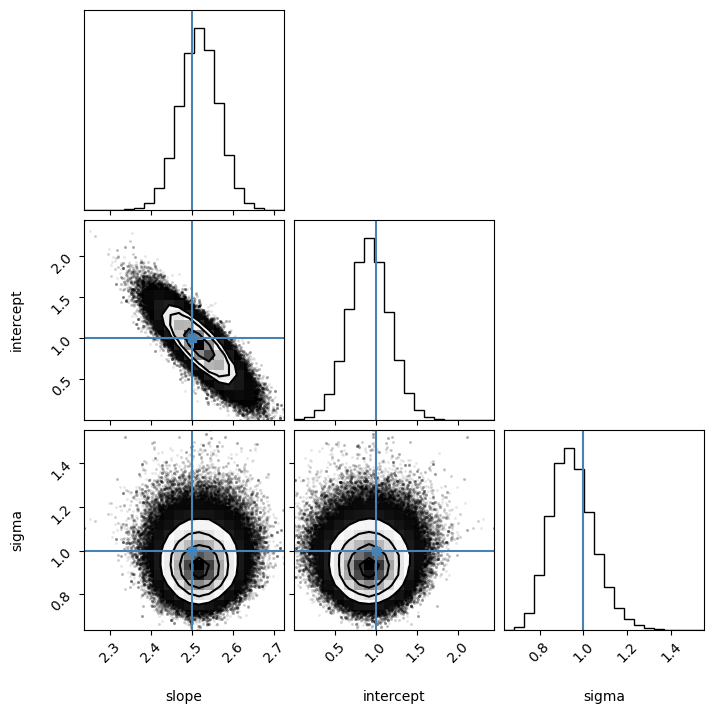

In [6]:
# corner plot dei campioni
fig = corner.corner(samples, labels=["slope", "intercept", "sigma"], truths=[true_slope, true_intercept, true_sigma])
plt.show()

Vogliamo distribuzioni ragionevolmente gaussiane, quindi ellissi nei corner. Se vediamo cose particolarmente lontane da ellissi, c'è qualcosa che non va. Se sono schiacciate ai bordi, il prior è troppo stretto. Se sono molto allungate, il prior è troppo largo. Se sono molto schiacciate, c'è qualcosa che non va nella likelihood (di solito manca un termine di errore, o l'errore è troppo piccolo). Se sono molto allungate, c'è qualcosa che non va nella likelihood (di solito manca un termine di errore, o l'errore è troppo grande). Se sono molto schiacciate e allungate, c'è qualcosa che non va nella likelihood (di solito manca un termine di errore, o l'errore è troppo piccolo o troppo grande).

In [8]:
# estrazione dei parametri stimati come mediana dei campioni
slope_median, intercept_median, sigma_median = np.median(samples, axis= 0)
print(f"Estimated slope: {slope_median:.2f}")
print(f"Estimated intercept: {intercept_median:.2f}")
print(f"Estimated sigma: {sigma_median:.2f}")

Estimated slope: 2.52
Estimated intercept: 0.92
Estimated sigma: 0.94


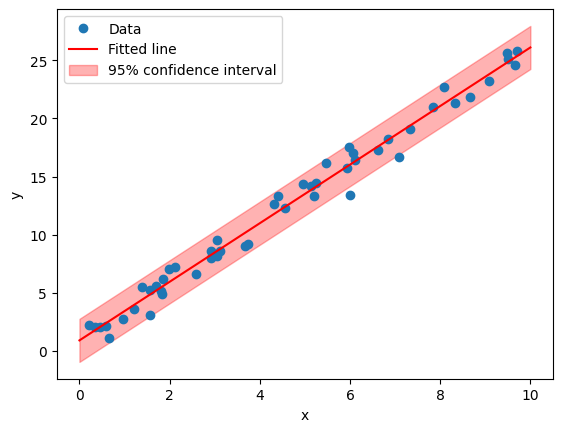

In [9]:
# plot dei dati e del fit

# dati originali
plt.plot(x, y, "o", label="Data")

# trend fittato
x_fit = np.linspace(0, 10, 100)
y_fit = slope_median * x_fit + intercept_median
plt.plot(x_fit, y_fit, label="Fitted line", color="red")

# intervallo di confidenza
y_fit_upper = y_fit + 1.96 * sigma_median
y_fit_lower = y_fit - 1.96 * sigma_median
plt.fill_between(x_fit, y_fit_lower, y_fit_upper, color="red", alpha=0.3, label="95% confidence interval")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()
